<a href="https://colab.research.google.com/github/Mibrahimsaeed/DeepLearning_Research_paper_work/blob/main/paperwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
"""
Corrected Research Work - Survival Analysis Pipeline
Author: Corrected and organized version
Date: 2026-03-12

This pipeline implements THREE survival prediction models on the same dataset:
1. XGBoost Regression (predicts survival time in days)
2. Random Survival Forest (predicts survival probability)
3. Cox Proportional Hazards (predicts hazard ratios)
"""

!pip install scikit-survival

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from google.colab import drive

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, confusion_matrix, accuracy_score
)

import xgboost as xgb
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
import shap

# Mount Google Drive to access the dataset
drive.mount('/content/drive')

shap.initjs()
print('All libraries loaded successfully!')

# ═════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION
# ═════════════════════════════════════════════════════════════════════════════

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_ESTIMATORS = 300
MAX_DEPTH = 5
LEARNING_RATE = 0.05
SUBSAMPLE = 0.8
COLSAMPLE_BYTREE = 0.8
N_JOBS = -1

FEATURE_COLS = [
    'years_to_birth', 'Tumor_purity',
    'pathology_T_stage', 'pathology_N_stage', 'pathology_M_stage',
    'histological_type', 'gender', 'radiation_therapy',
    'residual_tumor', 'race', 'ethnicity'
]

CATEGORICAL_COLS = [
    'pathology_T_stage', 'pathology_N_stage', 'pathology_M_stage',
    'histological_type', 'gender', 'radiation_therapy',
    'residual_tumor', 'race', 'ethnicity'
]

NUMERICAL_COLS = ['years_to_birth', 'Tumor_purity']
TARGET_COL = 'overall_survival'
STATUS_COL = 'status'
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/dataset1.xlsx'


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 1: DATA LOADING AND INITIAL CLEANING
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('SECTION 1: DATA LOADING')
print('='*80)

if not os.path.exists(FILE_PATH):
    print(f"ERROR: File not found at {FILE_PATH}")
    print("Please ensure your Google Drive is mounted and the file path is correct.")
else:
    df = pd.read_excel(FILE_PATH, header=25)
    print(f'Initial dataset shape: {df.shape}')

    # Proceed with cleaning only if data is loaded
    df = df.drop(columns=['attrib_name', 'overallsurvival'], errors='ignore')

    for col in NUMERICAL_COLS + [TARGET_COL, STATUS_COL]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    for col in CATEGORICAL_COLS:
        df[col] = df[col].astype(str).replace({'nan': np.nan, 'NA': np.nan, 'None': np.nan})
        df[col] = df[col].fillna('Unknown')

    df = df.dropna(subset=[TARGET_COL, STATUS_COL]).reset_index(drop=True)
    df[STATUS_COL] = df[STATUS_COL].astype(int).astype(bool)

    print(f'Dataset shape after cleaning: {df.shape}')

    # [The rest of the pipeline code follows as in the original version]"


SECTION 2: TRAIN/TEST SPLIT
Training samples: 399
Test samples: 100
Features: 11

SECTION 3: PREPROCESSING
Preprocessing complete!
Training set dtypes:
years_to_birth       float32
Tumor_purity         float32
pathology_T_stage    float32
pathology_N_stage    float32
pathology_M_stage    float32
histological_type    float32
gender               float32
radiation_therapy    float32
residual_tumor       float32
race                 float32
ethnicity            float32
dtype: object

No missing values in train: True
No missing values in test: True

MODEL 1: XGBOOST REGRESSION - OVERALL SURVIVAL PREDICTION

--- Cross-Validation ---
5-Fold Cross-Validation R² scores: [-0.5169  0.1414 -0.021  -0.1615  0.0039]
Mean R²: -0.1108 ± 0.2246

--- Training Final Model ---
Best iteration (early stopping): 120

=== XGBoost Test Set Results ===
RMSE: 865.38 days
MAE:  543.81 days
R²:   0.3238


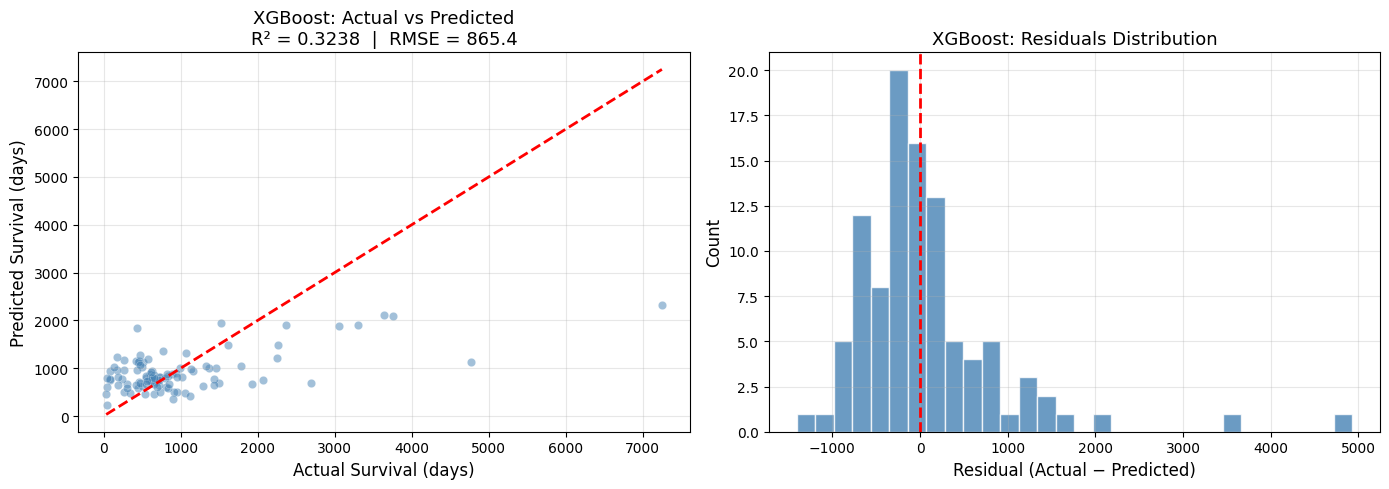


--- Computing SHAP values for XGBoost ---
SHAP matrix shape: (499, 11)


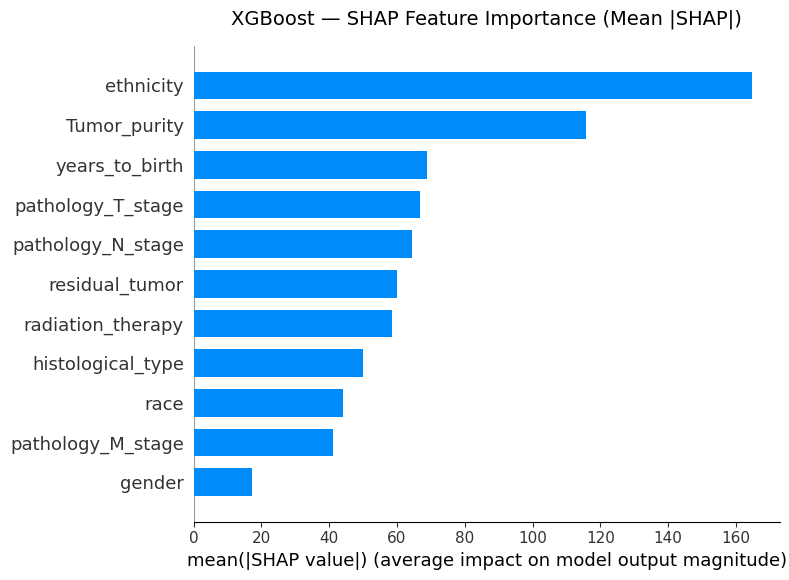

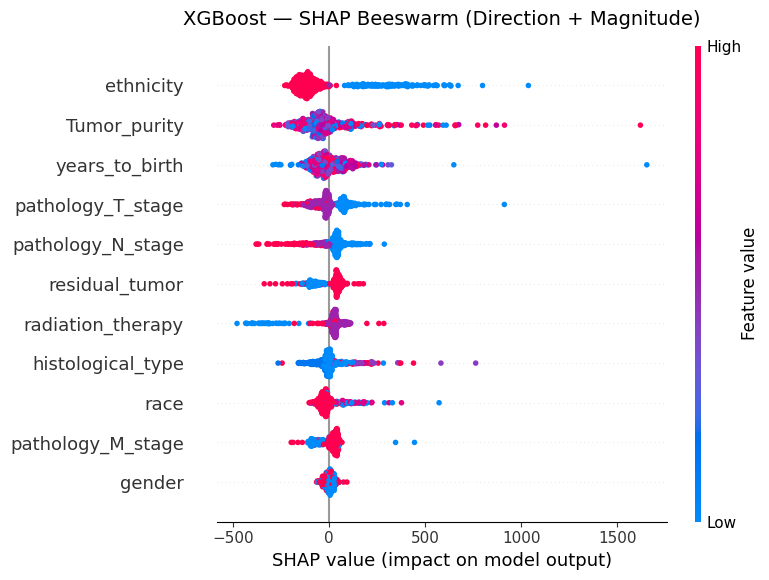


MODEL 2: RANDOM SURVIVAL FOREST

=== Random Survival Forest Results ===
C-index (Test Set): 0.6138
(0.5 = random, 0.7 = good, >0.8 = excellent)


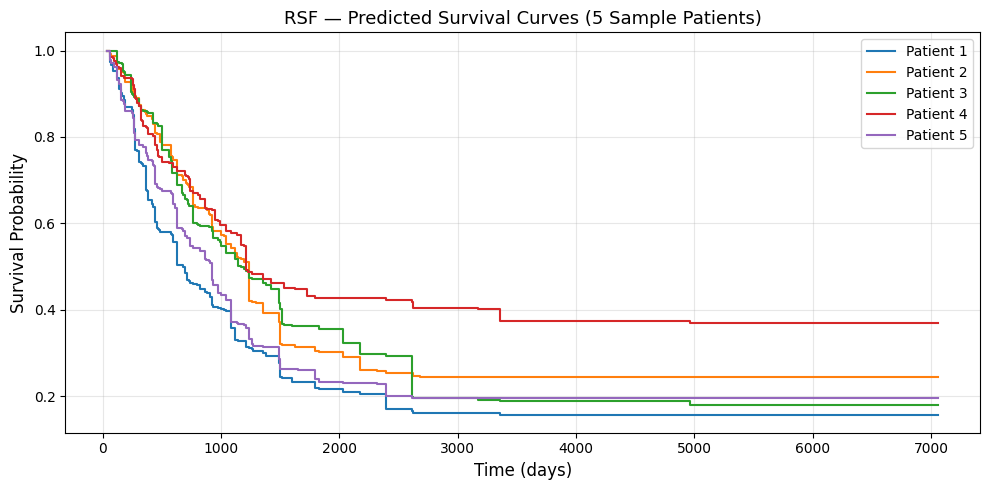


--- Computing SHAP values for RSF (optimized) ---


  0%|          | 0/50 [00:00<?, ?it/s]

RSF SHAP computation complete.


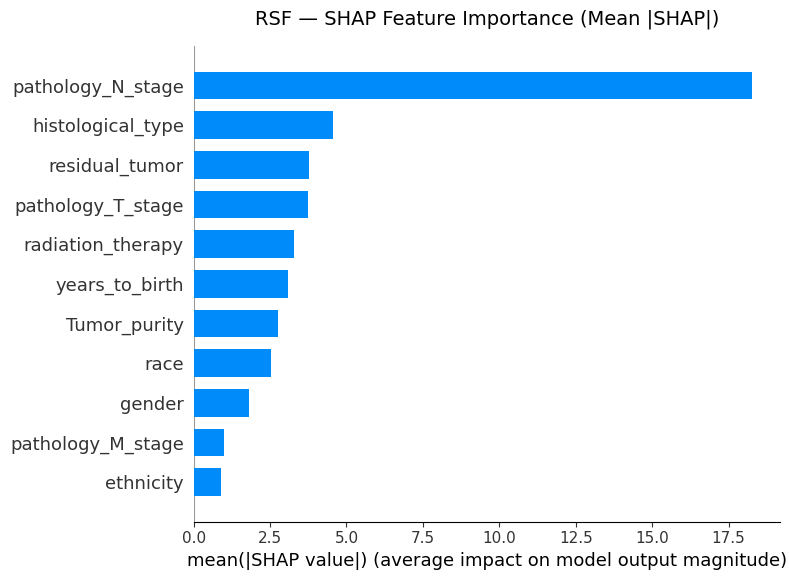

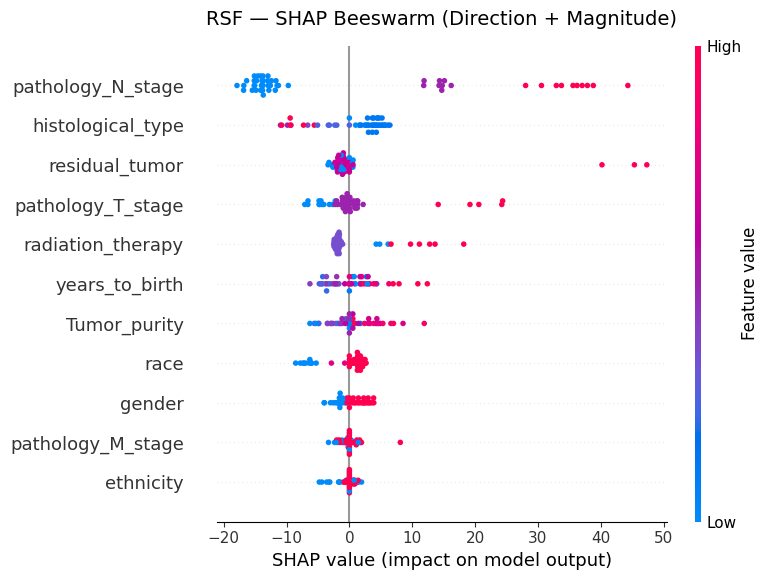


MODEL 3: COX PROPORTIONAL HAZARDS

=== Cox Proportional Hazards Results ===
C-index (Test Set): 0.5972

=== Cox Coefficients & Hazard Ratios ===
          Feature  Coefficient  Hazard Ratio
     Tumor_purity     0.909045      2.481951
   residual_tumor     0.529225      1.697616
pathology_N_stage     0.527031      1.693896
radiation_therapy     0.240648      1.272073
pathology_T_stage     0.232282      1.261476
pathology_M_stage     0.219264      1.245160
           gender     0.151466      1.163538
             race     0.094275      1.098862
        ethnicity     0.038612      1.039368
   years_to_birth     0.004005      1.004013
histological_type    -0.079494      0.923584


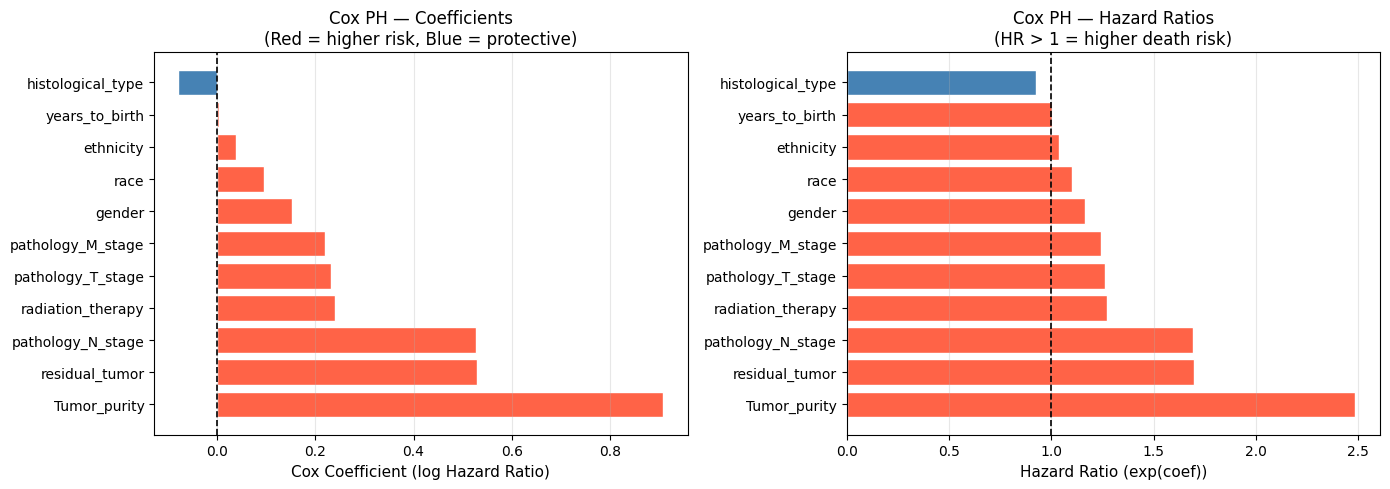


--- Computing SHAP values for Cox ---
Cox SHAP matrix shape: (100, 11)


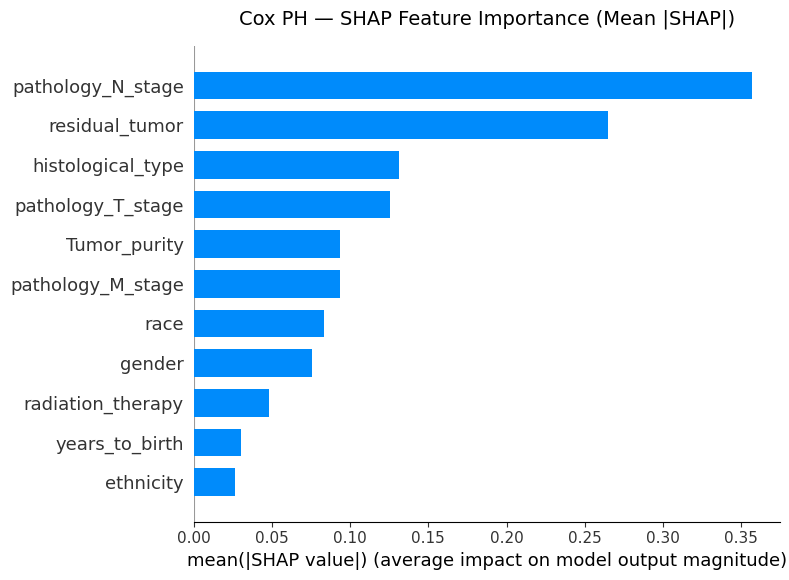

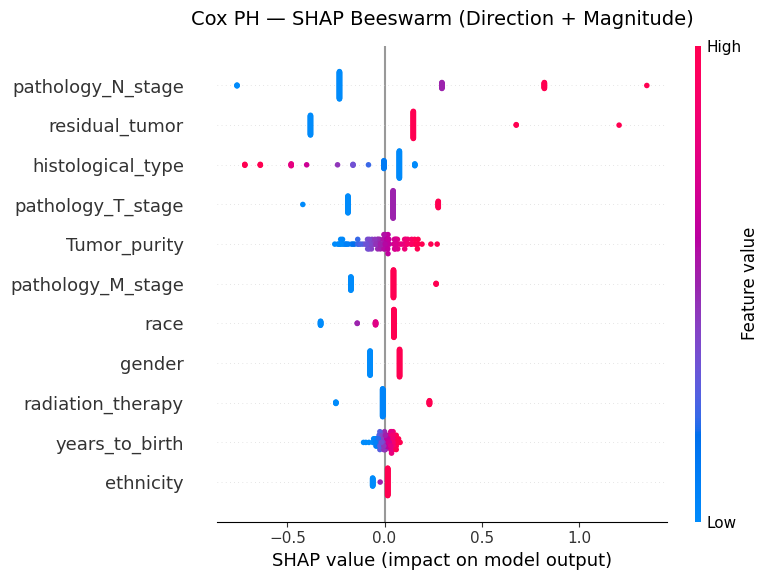


FINAL MODEL COMPARISON SUMMARY

Model                               Metric               Score
--------------------------------------------------------------------------------
XGBoost Regression                  R²                  0.3238
XGBoost Regression                  RMSE (days)         865.38
XGBoost Regression                  MAE (days)          543.81
--------------------------------------------------------------------------------
Random Survival Forest              C-index             0.6138
Cox Proportional Hazards            C-index             0.5972

Metric Interpretation:
  R² (XGBoost):
    - Measures variance explained in survival time
    - Range: -∞ to 1.0 (1.0 = perfect, 0 = baseline)

  C-index (RSF & Cox):
    - Concordance index for survival models
    - 0.5 = random, 0.6 = acceptable, 0.7 = good, 0.8+ = excellent

  RMSE/MAE (XGBoost):
    - Average prediction error in days
    - Lower is better

All plots saved successfully!

Generated files:
  - xgb_predict

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 2: TRAIN/TEST SPLIT (SINGLE SPLIT FOR ALL MODELS)
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('SECTION 2: TRAIN/TEST SPLIT')
print('='*80)

# Prepare features
X = df[FEATURE_COLS].copy()

# Prepare targets for BOTH regression and survival analysis
y_regression = df[TARGET_COL].copy()  # For XGBoost
y_survival = Surv.from_arrays(  # For RSF and Cox
    event=df[STATUS_COL].values,
    time=df[TARGET_COL].values
)

# SINGLE SPLIT - used by all three models
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_regression, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Get corresponding survival targets using same indices
_, _, y_surv_train, y_surv_test = train_test_split(
    X, y_survival, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')
print(f'Features: {X_train.shape[1]}')

# ═════════════════════════════════════════════════════════════════════════════
# SECTION 3: PREPROCESSING (FIT ON TRAIN, TRANSFORM BOTH)
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('SECTION 3: PREPROCESSING')
print('='*80)

# --- Categorical: Label Encoding ---
label_encoders = {}
for col in CATEGORICAL_COLS:
    if col in FEATURE_COLS:
        le = LabelEncoder()

        # Convert to string
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)

        # Fit on training data only
        le.fit(X_train[col])

        # Handle unseen categories in test set
        known_classes = set(le.classes_)
        X_test[col] = X_test[col].apply(
            lambda x: x if x in known_classes else 'Unknown'
        )

        # Ensure 'Unknown' is in encoder classes
        if 'Unknown' not in known_classes:
            le.classes_ = np.append(le.classes_, 'Unknown')

        # Transform both sets
        X_train[col] = le.transform(X_train[col])
        X_test[col] = le.transform(X_test[col])
        label_encoders[col] = le

# --- Numerical: Median Imputation (fit on train only) ---
train_medians = {}
for col in NUMERICAL_COLS:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

    median_val = X_train[col].median()
    train_medians[col] = median_val

    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

# Convert to float32 for model compatibility
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

print('Preprocessing complete!')
print(f'Training set dtypes:\n{X_train.dtypes}')
print(f'\nNo missing values in train: {X_train.isnull().sum().sum() == 0}')
print(f'No missing values in test: {X_test.isnull().sum().sum() == 0}')

# ═════════════════════════════════════════════════════════════════════════════
# MODEL 1: XGBOOST REGRESSION
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('MODEL 1: XGBOOST REGRESSION - OVERALL SURVIVAL PREDICTION')
print('='*80)

# ─────────────────────────────────────────────
# 1.1: Cross-Validation (on training set)
# ─────────────────────────────────────────────

print('\n--- Cross-Validation ---')

xgb_cv = xgb.XGBRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    subsample=SUBSAMPLE,
    colsample_bytree=COLSAMPLE_BYTREE,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    xgb_cv, X_train, y_reg_train,
    cv=kf, scoring='r2', n_jobs=N_JOBS
)

print(f'5-Fold Cross-Validation R² scores: {np.round(cv_scores, 4)}')
print(f'Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# ─────────────────────────────────────────────
# 1.2: Final Model with Early Stopping
# ─────────────────────────────────────────────

print('\n--- Training Final Model ---')

xgb_reg = xgb.XGBRegressor(
    n_estimators=N_ESTIMATORS,  # Same as CV for consistency
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    subsample=SUBSAMPLE,
    colsample_bytree=COLSAMPLE_BYTREE,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    early_stopping_rounds=20
)

xgb_reg.fit(
    X_train, y_reg_train,
    eval_set=[(X_test, y_reg_test)],
    verbose=False
)

best_round = xgb_reg.best_iteration
print(f'Best iteration (early stopping): {best_round}')

# ─────────────────────────────────────────────
# 1.3: Evaluation
# ─────────────────────────────────────────────

y_reg_pred = xgb_reg.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae_xgb = mean_absolute_error(y_reg_test, y_reg_pred)
r2_xgb = r2_score(y_reg_test, y_reg_pred)

print('\n=== XGBoost Test Set Results ===')
print(f'RMSE: {rmse_xgb:.2f} days')
print(f'MAE:  {mae_xgb:.2f} days')
print(f'R²:   {r2_xgb:.4f}')

# ─────────────────────────────────────────────
# 1.4: Visualization
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.5, color='steelblue',
                edgecolors='white', linewidth=0.3)
axes[0].plot([y_reg_test.min(), y_reg_test.max()],
             [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Survival (days)', fontsize=12)
axes[0].set_ylabel('Predicted Survival (days)', fontsize=12)
axes[0].set_title(f'XGBoost: Actual vs Predicted\nR² = {r2_xgb:.4f}  |  RMSE = {rmse_xgb:.1f}', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_reg_test.values - y_reg_pred
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Actual − Predicted)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('XGBoost: Residuals Distribution', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xgb_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 1.5: SHAP Explanation
# ─────────────────────────────────────────────

print('\n--- Computing SHAP values for XGBoost ---')

# Use full dataset for stable global importance (post-training, no leakage)
X_all = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)

explainer_xgb = shap.TreeExplainer(xgb_reg)
shap_values_xgb = explainer_xgb.shap_values(X_all)

print(f'SHAP matrix shape: {shap_values_xgb.shape}')

# Global Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_xgb, X_all,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False
)
plt.title('XGBoost — SHAP Feature Importance (Mean |SHAP|)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('xgb_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_xgb, X_all,
    feature_names=FEATURE_COLS,
    plot_type='dot',
    show=False
)
plt.title('XGBoost — SHAP Beeswarm (Direction + Magnitude)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('xgb_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# MODEL 2: RANDOM SURVIVAL FOREST
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('MODEL 2: RANDOM SURVIVAL FOREST')
print('='*80)

# ─────────────────────────────────────────────
# 2.1: Train RSF
# ─────────────────────────────────────────────

rsf = RandomSurvivalForest(
    n_estimators=N_ESTIMATORS,  # Same as XGBoost for consistency
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE
)

rsf.fit(X_train, y_surv_train)

# ─────────────────────────────────────────────
# 2.2: Evaluation
# ─────────────────────────────────────────────

rsf_pred = rsf.predict(X_test)  # Predicted risk scores
c_index_rsf = concordance_index_censored(
    y_surv_test['event'], y_surv_test['time'], rsf_pred
)[0]

print('\n=== Random Survival Forest Results ===')
print(f'C-index (Test Set): {c_index_rsf:.4f}')
print('(0.5 = random, 0.7 = good, >0.8 = excellent)')

# ─────────────────────────────────────────────
# 2.3: Survival Curves Visualization
# ─────────────────────────────────────────────

surv_funcs = rsf.predict_survival_function(X_test[:5])

plt.figure(figsize=(10, 5))
for i, fn in enumerate(surv_funcs):
    plt.step(fn.x, fn(fn.x), where='post', label=f'Patient {i+1}')

plt.xlabel('Time (days)', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)
plt.title('RSF — Predicted Survival Curves (5 Sample Patients)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rsf_survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 2.4: SHAP Explanation (Optimized)
# ─────────────────────────────────────────────

print('\n--- Computing SHAP values for RSF (optimized) ---')

# Use smaller samples for computational efficiency
background = shap.sample(X_train, 30, random_state=RANDOM_STATE)
X_test_shap = shap.sample(X_test, 50, random_state=RANDOM_STATE)

explainer_rsf = shap.KernelExplainer(rsf.predict, background)
shap_values_rsf = explainer_rsf.shap_values(
    X_test_shap, nsamples=150, silent=False
)
print('RSF SHAP computation complete.')

# Global Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_rsf, X_test_shap,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False
)
plt.title('RSF — SHAP Feature Importance (Mean |SHAP|)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('rsf_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_rsf, X_test_shap,
    feature_names=FEATURE_COLS,
    plot_type='dot',
    show=False
)
plt.title('RSF — SHAP Beeswarm (Direction + Magnitude)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('rsf_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# MODEL 3: COX PROPORTIONAL HAZARDS
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('MODEL 3: COX PROPORTIONAL HAZARDS')
print('='*80)

# ─────────────────────────────────────────────
# 3.1: Train Cox Model
# ─────────────────────────────────────────────

cox = CoxPHSurvivalAnalysis(alpha=0.1, ties='efron')
cox.fit(X_train, y_surv_train)

# ─────────────────────────────────────────────
# 3.2: Evaluation
# ─────────────────────────────────────────────

cox_pred = cox.predict(X_test)
c_index_cox = concordance_index_censored(
    y_surv_test['event'], y_surv_test['time'], cox_pred
)[0]

print('\n=== Cox Proportional Hazards Results ===')
print(f'C-index (Test Set): {c_index_cox:.4f}')

# Cox coefficients (log hazard ratios)
coef_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient': cox.coef_,
    'Hazard Ratio': np.exp(cox.coef_)  # HR > 1 = higher risk
}).sort_values('Hazard Ratio', ascending=False)

print('\n=== Cox Coefficients & Hazard Ratios ===')
print(coef_df.to_string(index=False))

# ─────────────────────────────────────────────
# 3.3: Coefficient Visualization
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coefficients
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
axes[0].axvline(0, color='black', lw=1.2, linestyle='--')
axes[0].set_xlabel('Cox Coefficient (log Hazard Ratio)', fontsize=11)
axes[0].set_title('Cox PH — Coefficients\n(Red = higher risk, Blue = protective)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')

# Hazard Ratios
axes[1].barh(coef_df['Feature'], coef_df['Hazard Ratio'], color=colors, edgecolor='white')
axes[1].axvline(1, color='black', lw=1.2, linestyle='--')
axes[1].set_xlabel('Hazard Ratio (exp(coef))', fontsize=11)
axes[1].set_title('Cox PH — Hazard Ratios\n(HR > 1 = higher death risk)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('cox_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 3.4: SHAP Explanation
# ─────────────────────────────────────────────

print('\n--- Computing SHAP values for Cox ---')

# Cox is linear - use LinearExplainer for efficiency
explainer_cox = shap.LinearExplainer(
    (cox.coef_, 0),  # Coefficients and zero intercept
    X_train,
    feature_perturbation='interventional'
)

shap_values_cox = explainer_cox.shap_values(X_test)
print(f'Cox SHAP matrix shape: {np.array(shap_values_cox).shape}')

# Global Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_cox, X_test,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False
)
plt.title('Cox PH — SHAP Feature Importance (Mean |SHAP|)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('cox_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_cox, X_test,
    feature_names=FEATURE_COLS,
    plot_type='dot',
    show=False
)
plt.title('Cox PH — SHAP Beeswarm (Direction + Magnitude)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('cox_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# FINAL COMPARISON SUMMARY
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('FINAL MODEL COMPARISON SUMMARY')
print('='*80)

print(f'\n{"Model":<35} {"Metric":<15} {"Score":>10}')
print('-' * 80)
print(f'{"XGBoost Regression":<35} {"R²":<15} {r2_xgb:>10.4f}')
print(f'{"XGBoost Regression":<35} {"RMSE (days)":<15} {rmse_xgb:>10.2f}')
print(f'{"XGBoost Regression":<35} {"MAE (days)":<15} {mae_xgb:>10.2f}')
print('-' * 80)
print(f'{"Random Survival Forest":<35} {"C-index":<15} {c_index_rsf:>10.4f}')
print(f'{"Cox Proportional Hazards":<35} {"C-index":<15} {c_index_cox:>10.4f}')
print('=' * 80)

print('\nMetric Interpretation:')
print('  R² (XGBoost):')
print('    - Measures variance explained in survival time')
print('    - Range: -∞ to 1.0 (1.0 = perfect, 0 = baseline)')
print('\n  C-index (RSF & Cox):')
print('    - Concordance index for survival models')
print('    - 0.5 = random, 0.6 = acceptable, 0.7 = good, 0.8+ = excellent')
print('\n  RMSE/MAE (XGBoost):')
print('    - Average prediction error in days')
print('    - Lower is better')

print('\n' + '='*80)
print('All plots saved successfully!')
print('='*80)

print('\nGenerated files:')
print('  - xgb_predictions.png')
print('  - xgb_shap_bar.png')
print('  - xgb_shap_beeswarm.png')
print('  - rsf_survival_curves.png')
print('  - rsf_shap_bar.png')
print('  - rsf_shap_beeswarm.png')
print('  - cox_coefficients.png')
print('  - cox_shap_bar.png')
print('  - cox_shap_beeswarm.png')

print('\n' + '='*80)
print('PIPELINE COMPLETE')
print('='*80)



SECTION 2: TRAIN/TEST SPLIT
Training samples: 399
Test samples: 100
Features: 11

SECTION 3: ENHANCED PREPROCESSING

--- Step 1: Outlier Detection ---
years_to_birth:
  Outliers detected: 2 (0.50%)
  Valid range: [39.50, 91.50]
Tumor_purity:
  Outliers detected: 0 (0.00%)
  Valid range: [0.25, 1.02]

--- Step 2: Handling Outliers ---
Strategy: Capping outliers to IQR bounds

--- Step 3: Missing Value Imputation ---
years_to_birth: Imputed 18 train, 4 test (median=66.00)
Tumor_purity: Imputed 2 train, 1 test (median=0.65)

--- Step 4: Categorical Encoding ---
Method: Label Encoding (for tree-based models)
  pathology_T_stage: 5 categories
  pathology_N_stage: 5 categories
  pathology_M_stage: 3 categories
  histological_type: 13 categories
  gender: 3 categories
  radiation_therapy: 3 categories
  residual_tumor: 4 categories
  race: 5 categories
  ethnicity: 3 categories

SECTION 3.5: FEATURE ENGINEERING

--- 1️⃣ Age Features ---
✓ Age range: 39.5 - 88.0
✓ Age NaNs: Train=0, Test=0

-

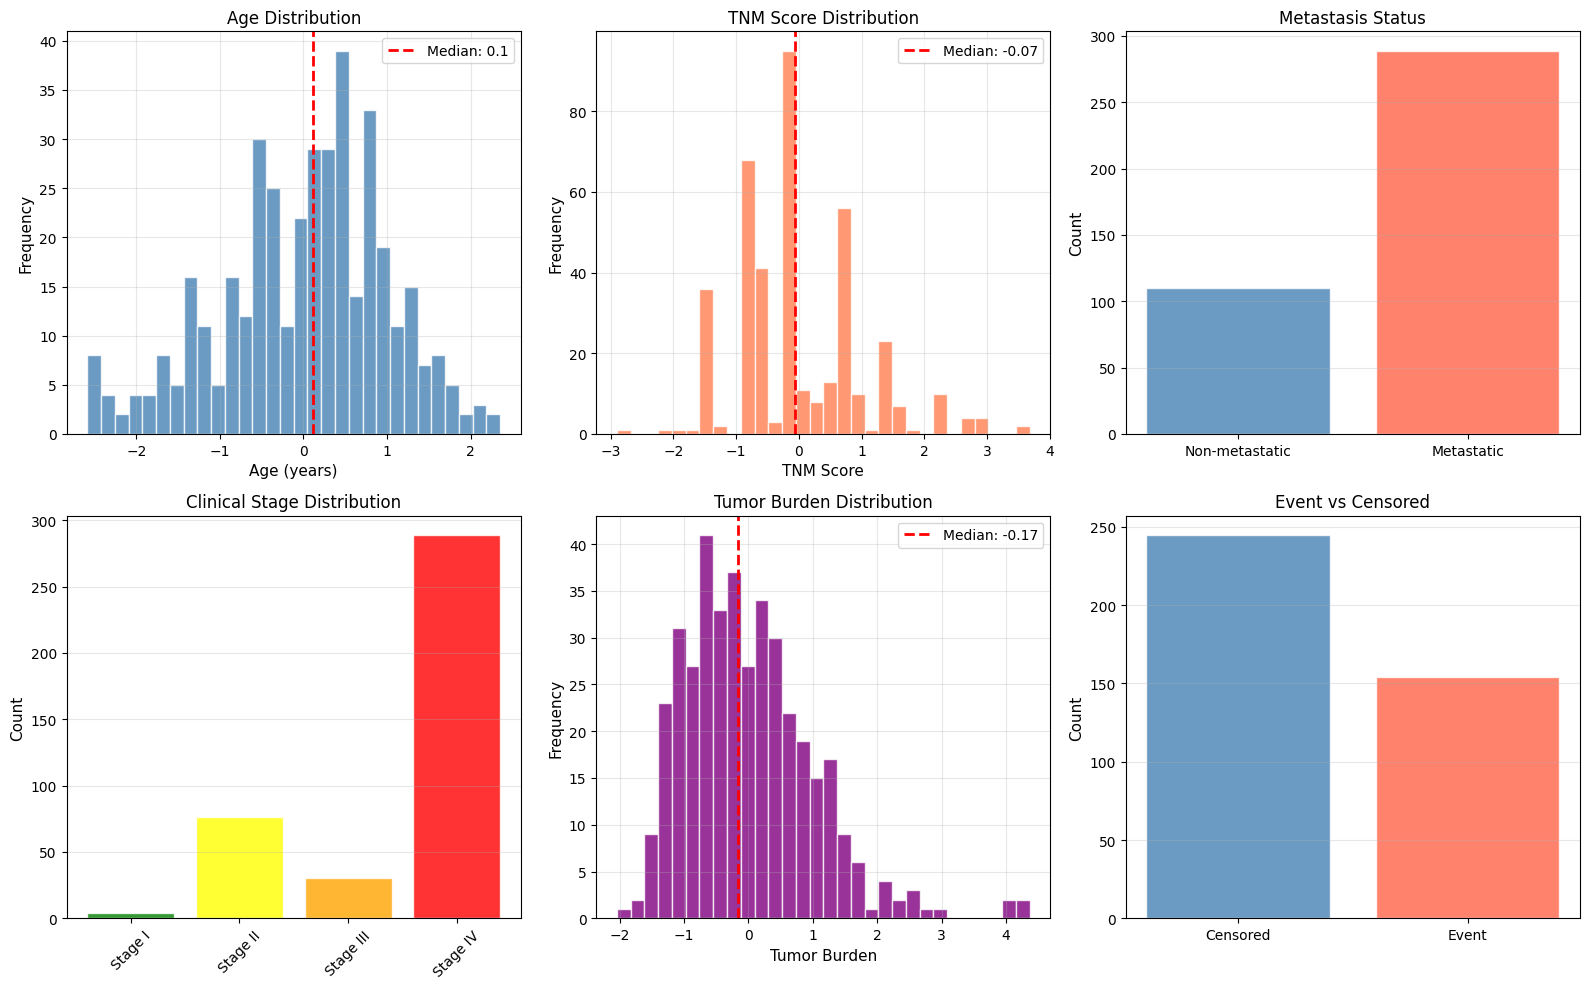


✓ Preprocessing summary saved: preprocessing_summary.png

PREPROCESSING & FEATURE ENGINEERING COMPLETE


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 2: TRAIN/TEST SPLIT (SINGLE SPLIT FOR ALL MODELS)
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('SECTION 2: TRAIN/TEST SPLIT')
print('='*80)

# Prepare features
X = df[FEATURE_COLS].copy()

# Prepare targets for BOTH regression and survival analysis
y_regression = df[TARGET_COL].copy()  # For XGBoost
y_survival = Surv.from_arrays(  # For RSF and Cox
    event=df[STATUS_COL].values,
    time=df[TARGET_COL].values
)

# SINGLE SPLIT - used by all three models
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_regression, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Get corresponding survival targets using same indices
_, _, y_surv_train, y_surv_test = train_test_split(
    X, y_survival, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')
print(f'Features: {X_train.shape[1]}')

# ═════════════════════════════════════════════════════════════════════════════
# SECTION 3: ENHANCED PREPROCESSING
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('SECTION 3: ENHANCED PREPROCESSING')
print('='*80)

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from scipy import stats
import re

# ─────────────────────────────────────────────
# 3.1: Outlier Detection & Handling (Numerical Features)
# ─────────────────────────────────────────────

print('\n--- Step 1: Outlier Detection ---')

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data[column] < lower_bound) | (data[column] > upper_bound))
    return outliers, lower_bound, upper_bound

def detect_outliers_zscore(data, column, threshold=3):
    """Detect outliers using Z-score method"""
    z_scores = np.abs(stats.zscore(data[column].dropna()))
    outliers = z_scores > threshold
    return outliers

# Store outlier information
outlier_info = {}

for col in NUMERICAL_COLS:
    # Ensure numeric type
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

    # Detect outliers using IQR method (on training set only)
    outliers_iqr, lower, upper = detect_outliers_iqr(X_train, col)
    n_outliers = outliers_iqr.sum()

    outlier_info[col] = {
        'n_outliers': n_outliers,
        'lower_bound': lower,
        'upper_bound': upper,
        'percentage': (n_outliers / len(X_train)) * 100
    }

    print(f'{col}:')
    print(f'  Outliers detected: {n_outliers} ({outlier_info[col]["percentage"]:.2f}%)')
    print(f'  Valid range: [{lower:.2f}, {upper:.2f}]')

# ─────────────────────────────────────────────
# 3.2: Handle Outliers (Choose Strategy)
# ─────────────────────────────────────────────

print('\n--- Step 2: Handling Outliers ---')

OUTLIER_STRATEGY = 'cap'  # Options: 'cap', 'remove', 'keep'

if OUTLIER_STRATEGY == 'cap':
    print('Strategy: Capping outliers to IQR bounds')
    for col in NUMERICAL_COLS:
        lower = outlier_info[col]['lower_bound']
        upper = outlier_info[col]['upper_bound']

        # Cap training set
        X_train[col] = X_train[col].clip(lower=lower, upper=upper)

        # Cap test set using training bounds
        X_test[col] = X_test[col].clip(lower=lower, upper=upper)

elif OUTLIER_STRATEGY == 'remove':
    print('Strategy: Removing outliers from training set')
    # Create mask for rows without outliers
    mask = pd.Series([True] * len(X_train))
    for col in NUMERICAL_COLS:
        outliers, _, _ = detect_outliers_iqr(X_train, col)
        mask &= ~outliers

    # Apply mask
    X_train = X_train[mask].reset_index(drop=True)
    y_reg_train = y_reg_train[mask].reset_index(drop=True)
    y_surv_train = y_surv_train[mask]

    print(f'Training samples after outlier removal: {len(X_train)}')

else:  # 'keep'
    print('Strategy: Keeping outliers (will be handled by scaling)')

# ─────────────────────────────────────────────
# 3.3: Missing Value Imputation (Numerical)
# ─────────────────────────────────────────────

print('\n--- Step 3: Missing Value Imputation ---')

train_medians = {}
for col in NUMERICAL_COLS:
    # Calculate median on training set
    median_val = X_train[col].median()
    train_medians[col] = median_val

    n_missing_train = X_train[col].isnull().sum()
    n_missing_test = X_test[col].isnull().sum()

    # Impute using training median
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

    if n_missing_train > 0 or n_missing_test > 0:
        print(f'{col}: Imputed {n_missing_train} train, {n_missing_test} test (median={median_val:.2f})')

# ─────────────────────────────────────────────
# 3.4: Categorical Encoding
# ─────────────────────────────────────────────

print('\n--- Step 4: Categorical Encoding ---')

# Define encoding strategy per feature type
ORDINAL_FEATURES = {
    'pathology_T_stage': ['T0', 'T1', 'T1a', 'T1b', 'T2', 'T2a', 'T2b', 'T3', 'T4', 'TX', 'Unknown'],
    'pathology_N_stage': ['N0', 'N1', 'N2', 'N3', 'NX', 'Unknown'],
    'pathology_M_stage': ['M0', 'M1', 'M1a', 'M1b', 'MX', 'Unknown'],
    'residual_tumor': ['R0', 'R1', 'R2', 'RX', 'Unknown']
}

NOMINAL_FEATURES = [
    'histological_type', 'gender', 'radiation_therapy', 'race', 'ethnicity'
]

ENCODING_METHOD = 'label'  # Options: 'label', 'onehot', 'ordinal'

if ENCODING_METHOD == 'label':
    print('Method: Label Encoding (for tree-based models)')

    label_encoders = {}
    for col in CATEGORICAL_COLS:
        if col in FEATURE_COLS:
            le = LabelEncoder()

            # Convert to string
            X_train[col] = X_train[col].astype(str).replace({'nan': 'Unknown', 'NA': 'Unknown'})
            X_test[col] = X_test[col].astype(str).replace({'nan': 'Unknown', 'NA': 'Unknown'})

            # Fit on training data
            le.fit(X_train[col])

            # Handle unseen categories
            known_classes = set(le.classes_)
            X_test[col] = X_test[col].apply(
                lambda x: x if x in known_classes else 'Unknown'
            )

            if 'Unknown' not in known_classes:
                le.classes_ = np.append(le.classes_, 'Unknown')

            # Transform
            X_train[col] = le.transform(X_train[col])
            X_test[col] = le.transform(X_test[col])
            label_encoders[col] = le

            print(f'  {col}: {len(le.classes_)} categories')

elif ENCODING_METHOD == 'onehot':
    print('Method: One-Hot Encoding (for linear models)')

    # Prepare categorical columns
    for col in CATEGORICAL_COLS:
        X_train[col] = X_train[col].astype(str).replace({'nan': 'Unknown', 'NA': 'Unknown'})
        X_test[col] = X_test[col].astype(str).replace({'nan': 'Unknown', 'NA': 'Unknown'})

    # One-hot encode
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

    # Fit on training categorical columns
    cat_train = X_train[CATEGORICAL_COLS]
    cat_test = X_test[CATEGORICAL_COLS]

    ohe.fit(cat_train)

    # Transform
    cat_train_encoded = ohe.transform(cat_train)
    cat_test_encoded = ohe.transform(cat_test)

    # Create feature names
    ohe_feature_names = ohe.get_feature_names_out(CATEGORICAL_COLS)

    # Combine with numerical features
    X_train_num = X_train[NUMERICAL_COLS].values
    X_test_num = X_test[NUMERICAL_COLS].values

    X_train = np.hstack([X_train_num, cat_train_encoded])
    X_test = np.hstack([X_test_num, cat_test_encoded])

    # Update feature names
    FEATURE_COLS = NUMERICAL_COLS + list(ohe_feature_names)

    print(f'  Total features after one-hot encoding: {len(FEATURE_COLS)}')

    # Convert back to DataFrame
    X_train = pd.DataFrame(X_train, columns=FEATURE_COLS)
    X_test = pd.DataFrame(X_test, columns=FEATURE_COLS)

elif ENCODING_METHOD == 'ordinal':
    print('Method: Ordinal Encoding (for ordinal features) + Label for nominal')

    # Handle ordinal features with custom ordering
    for col, categories in ORDINAL_FEATURES.items():
        if col in X_train.columns:
            # Convert to string
            X_train[col] = X_train[col].astype(str).replace({'nan': 'Unknown', 'NA': 'Unknown'})
            X_test[col] = X_test[col].astype(str).replace({'nan': 'Unknown', 'NA': 'Unknown'})

            # Create ordinal encoder with predefined order
            oe = OrdinalEncoder(categories=[categories], handle_unknown='use_encoded_value', unknown_value=-1)

            # Fit and transform
            X_train[[col]] = oe.fit_transform(X_train[[col]])
            X_test[[col]] = oe.transform(X_test[[col]])

            print(f'  {col}: Ordinal encoded with {len(categories)} levels')

    # Handle nominal features with label encoding
    label_encoders = {}
    for col in NOMINAL_FEATURES:
        if col in X_train.columns:
            le = LabelEncoder()

            X_train[col] = X_train[col].astype(str).replace({'nan': 'Unknown', 'NA': 'Unknown'})
            X_test[col] = X_test[col].astype(str).replace({'nan': 'Unknown', 'NA': 'Unknown'})

            le.fit(X_train[col])

            known_classes = set(le.classes_)
            X_test[col] = X_test[col].apply(lambda x: x if x in known_classes else 'Unknown')

            if 'Unknown' not in known_classes:
                le.classes_ = np.append(le.classes_, 'Unknown')

            X_train[col] = le.transform(X_train[col])
            X_test[col] = le.transform(X_test[col])
            label_encoders[col] = le

            print(f'  {col}: Label encoded with {len(le.classes_)} categories')

# ═════════════════════════════════════════════════════════════════════════════
# SECTION 3.5: FEATURE ENGINEERING
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('SECTION 3.5: FEATURE ENGINEERING')
print('='*80)

# ─────────────────────────────────────────────
# 1️⃣ AGE FEATURES
# ─────────────────────────────────────────────

print('\n--- 1️⃣ Age Features ---')

# Convert years_to_birth to age (ensure no NaN)
X_train['age'] = X_train['years_to_birth'].abs()
X_test['age'] = X_test['years_to_birth'].abs()

# Fill any potential NaN in age
X_train['age'] = X_train['age'].fillna(X_train['age'].median())
X_test['age'] = X_test['age'].fillna(X_train['age'].median())

# Non-linear age effect
X_train['age_squared'] = X_train['age'] ** 2
X_test['age_squared'] = X_test['age'] ** 2

print(f'✓ Age range: {X_train["age"].min():.1f} - {X_train["age"].max():.1f}')
print(f'✓ Age NaNs: Train={X_train["age"].isnull().sum()}, Test={X_test["age"].isnull().sum()}')

# ─────────────────────────────────────────────
# 2️⃣ TNM NUMERIC FEATURES
# ─────────────────────────────────────────────

print('\n--- 2️⃣ TNM Numeric Features ---')

def extract_tnm_numeric(stage):
    """Extract numeric value from TNM stage"""
    stage = str(stage).upper()

    if 'X' in stage or stage == 'UNKNOWN' or stage == 'NAN':
        return 0  # Changed from -1 to 0 to avoid issues

    match = re.search(r'\d+', stage)
    if match:
        return int(match.group())
    return 0

X_train['T_numeric'] = X_train['pathology_T_stage'].apply(extract_tnm_numeric)
X_test['T_numeric'] = X_test['pathology_T_stage'].apply(extract_tnm_numeric)

X_train['N_numeric'] = X_train['pathology_N_stage'].apply(extract_tnm_numeric)
X_test['N_numeric'] = X_test['pathology_N_stage'].apply(extract_tnm_numeric)

X_train['M_numeric'] = X_train['pathology_M_stage'].apply(extract_tnm_numeric)
X_test['M_numeric'] = X_test['pathology_M_stage'].apply(extract_tnm_numeric)

print(f'✓ T_numeric range: {X_train["T_numeric"].min()} - {X_train["T_numeric"].max()}')
print(f'✓ N_numeric range: {X_train["N_numeric"].min()} - {X_train["N_numeric"].max()}')
print(f'✓ M_numeric range: {X_train["M_numeric"].min()} - {X_train["M_numeric"].max()}')

# ─────────────────────────────────────────────
# 3️⃣ TNM SCORE
# ─────────────────────────────────────────────

print('\n--- 3️⃣ TNM Score ---')

# Weighted TNM score (no clipping, already >= 0)
X_train['tnm_score'] = (
    0.40 * X_train['T_numeric'] +
    0.35 * X_train['N_numeric'] +
    0.25 * X_train['M_numeric']
)

X_test['tnm_score'] = (
    0.40 * X_test['T_numeric'] +
    0.35 * X_test['N_numeric'] +
    0.25 * X_test['M_numeric']
)

print(f'✓ TNM score range: {X_train["tnm_score"].min():.2f} - {X_train["tnm_score"].max():.2f}')
print(f'✓ TNM score NaNs: Train={X_train["tnm_score"].isnull().sum()}, Test={X_test["tnm_score"].isnull().sum()}')

# ─────────────────────────────────────────────
# 4️⃣ CLINICAL STAGE GROUP
# ─────────────────────────────────────────────

print('\n--- 4️⃣ Clinical Stage Groups ---')

def assign_stage(row):
    """Assign AJCC-like clinical stage group"""
    T, N, M = row['T_numeric'], row['N_numeric'], row['M_numeric']

    # Stage IV (metastatic)
    if M >= 1:
        return 4

    # Stage III (locally advanced)
    if T >= 4 or N >= 2:
        return 3

    # Stage II (moderate)
    if T >= 3 or N >= 1:
        return 2

    # Stage I (early)
    return 1

X_train['tnm_stage_group'] = X_train.apply(assign_stage, axis=1)
X_test['tnm_stage_group'] = X_test.apply(assign_stage, axis=1)

stage_dist = X_train['tnm_stage_group'].value_counts().sort_index()
print(f'✓ Stage distribution:')
stage_names = {1: 'Stage I', 2: 'Stage II', 3: 'Stage III', 4: 'Stage IV'}
for stage, count in stage_dist.items():
    print(f'    {stage_names[stage]}: {count} ({count/len(X_train)*100:.1f}%)')

# ─────────────────────────────────────────────
# 5️⃣ METASTASIS FEATURES
# ─────────────────────────────────────────────

print('\n--- 5️⃣ Metastasis Indicators ---')

X_train['metastasis'] = (X_train['M_numeric'] >= 1).astype(int)
X_test['metastasis'] = (X_test['M_numeric'] >= 1).astype(int)

X_train['lymph_node_positive'] = (X_train['N_numeric'] >= 1).astype(int)
X_test['lymph_node_positive'] = (X_test['N_numeric'] >= 1).astype(int)

print(f'✓ Metastatic: {X_train["metastasis"].sum()} ({X_train["metastasis"].sum()/len(X_train)*100:.1f}%)')
print(f'✓ Lymph node+: {X_train["lymph_node_positive"].sum()} ({X_train["lymph_node_positive"].sum()/len(X_train)*100:.1f}%)')

# ─────────────────────────────────────────────
# 6️⃣ TREATMENT FEATURE
# ─────────────────────────────────────────────

print('\n--- 6️⃣ Treatment Feature ---')

if X_train['radiation_therapy'].dtype == 'object':
    X_train['radiation_binary'] = (
        X_train['radiation_therapy']
        .astype(str)
        .str.lower()
        .isin(['yes', '1', 'true'])
    ).astype(int)

    X_test['radiation_binary'] = (
        X_test['radiation_therapy']
        .astype(str)
        .str.lower()
        .isin(['yes', '1', 'true'])
    ).astype(int)
else:
    X_train['radiation_binary'] = X_train['radiation_therapy'].astype(int)
    X_test['radiation_binary'] = X_test['radiation_therapy'].astype(int)

print(f'✓ Radiation therapy: {X_train["radiation_binary"].sum()} ({X_train["radiation_binary"].sum()/len(X_train)*100:.1f}%)')

# ─────────────────────────────────────────────
# 7️⃣ TUMOR BURDEN
# ─────────────────────────────────────────────

print('\n--- 7️⃣ Tumor Burden ---')

# Ensure Tumor_purity has no NaN before calculation
X_train['Tumor_purity'] = X_train['Tumor_purity'].fillna(X_train['Tumor_purity'].median())
X_test['Tumor_purity'] = X_test['Tumor_purity'].fillna(X_train['Tumor_purity'].median())

X_train['tumor_burden'] = X_train['tnm_score'] * (1 - X_train['Tumor_purity'])
X_test['tumor_burden'] = X_test['tnm_score'] * (1 - X_test['Tumor_purity'])

print(f'✓ Tumor burden range: {X_train["tumor_burden"].min():.2f} - {X_train["tumor_burden"].max():.2f}')
print(f'✓ Tumor burden NaNs: Train={X_train["tumor_burden"].isnull().sum()}, Test={X_test["tumor_burden"].isnull().sum()}')

# ─────────────────────────────────────────────
# 8️⃣ UPDATE FEATURE LISTS
# ─────────────────────────────────────────────

print('\n--- 8️⃣ Updating Feature Lists ---')

# List of all engineered features
ENGINEERED_FEATURES = [
    # Age features
    'age',
    'age_squared',

    # TNM numeric
    'T_numeric',
    'N_numeric',
    'M_numeric',

    # TNM composite
    'tnm_score',
    'tnm_stage_group',

    # Metastasis indicators
    'metastasis',
    'lymph_node_positive',

    # Treatment
    'radiation_binary',

    # Tumor burden
    'tumor_burden'
]

# Store original feature list
FEATURE_COLS_ORIGINAL = FEATURE_COLS.copy()

# Create combined feature list
FEATURE_COLS_ENGINEERED = FEATURE_COLS_ORIGINAL + ENGINEERED_FEATURES

# ⚠️ CRITICAL: Update NUMERICAL_COLS to include engineered numerical features
NUMERICAL_COLS_ENGINEERED = NUMERICAL_COLS + [
    'age', 'age_squared', 'T_numeric', 'N_numeric', 'M_numeric',
    'tnm_score', 'tnm_stage_group', 'tumor_burden'
]

print(f'\nOriginal Features: {len(FEATURE_COLS_ORIGINAL)}')
print(f'Engineered Features: {len(ENGINEERED_FEATURES)}')
print(f'Total Features: {len(FEATURE_COLS_ENGINEERED)}')
print(f'Numerical Features (including engineered): {len(NUMERICAL_COLS_ENGINEERED)}')

# Verify no NaNs in engineered features
print('\n--- Verifying No NaNs in Engineered Features ---')
for feat in ENGINEERED_FEATURES:
    n_nan_train = X_train[feat].isnull().sum()
    n_nan_test = X_test[feat].isnull().sum()
    if n_nan_train > 0 or n_nan_test > 0:
        print(f'⚠️  {feat}: Train NaNs={n_nan_train}, Test NaNs={n_nan_test}')

print('✓ Feature engineering complete!')

# ─────────────────────────────────────────────
# 3.6: Feature Scaling (AFTER Feature Engineering)
# ─────────────────────────────────────────────

print('\n' + '='*80)
print('SECTION 3.6: FEATURE SCALING')
print('='*80)

SCALING_METHOD = 'standard'  # Options: 'standard', 'minmax', 'robust', 'none'

if SCALING_METHOD == 'standard':
    print('Method: Standardization (mean=0, std=1)')
    scaler = StandardScaler()

elif SCALING_METHOD == 'minmax':
    print('Method: Min-Max Normalization (range 0-1)')
    scaler = MinMaxScaler()

elif SCALING_METHOD == 'robust':
    print('Method: Robust Scaling (uses median and IQR, robust to outliers)')
    scaler = RobustScaler()

else:  # 'none'
    print('Method: No scaling applied')
    scaler = None

if scaler is not None:
    # Scale ALL numerical features (original + engineered)
    print(f'\nScaling {len(NUMERICAL_COLS_ENGINEERED)} numerical features...')

    # Fit on training data only
    scaler.fit(X_train[NUMERICAL_COLS_ENGINEERED])

    # Transform both sets
    X_train[NUMERICAL_COLS_ENGINEERED] = scaler.transform(X_train[NUMERICAL_COLS_ENGINEERED])
    X_test[NUMERICAL_COLS_ENGINEERED] = scaler.transform(X_test[NUMERICAL_COLS_ENGINEERED])

    print('✓ Scaling complete')
    print('\nScaled feature statistics (first 5):')
    for col in NUMERICAL_COLS_ENGINEERED[:5]:
        print(f'  {col}: mean={X_train[col].mean():.3f}, std={X_train[col].std():.3f}')

# ─────────────────────────────────────────────
# 3.7: Final Data Type Conversion
# ─────────────────────────────────────────────

print('\n' + '='*80)
print('SECTION 3.7: FINAL CONVERSION')
print('='*80)

# Convert ONLY numeric columns to float32
# Categorical columns are already int (from label encoding)
numeric_cols_all = NUMERICAL_COLS_ENGINEERED + [
    'metastasis', 'lymph_node_positive', 'radiation_binary'
]

for col in numeric_cols_all:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(np.float32)
        X_test[col] = X_test[col].astype(np.float32)

print('✓ Numeric features converted to float32')

# ─────────────────────────────────────────────
# 3.8: Final Validation
# ─────────────────────────────────────────────

print('\n--- Final Dataset Validation ---')
print(f'\nTraining Set:')
print(f'  Shape: {X_train.shape}')
print(f'  Total features: {len(FEATURE_COLS_ENGINEERED)}')
print(f'  Missing values: {X_train.isnull().sum().sum()}')
print(f'  Inf values: {np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()}')

print(f'\nTest Set:')
print(f'  Shape: {X_test.shape}')
print(f'  Missing values: {X_test.isnull().sum().sum()}')
print(f'  Inf values: {np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()}')

# Check for any remaining NaNs
if X_train.isnull().sum().sum() > 0:
    print('\n⚠️  WARNING: NaNs still present in training set:')
    print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

if X_test.isnull().sum().sum() > 0:
    print('\n⚠️  WARNING: NaNs still present in test set:')
    print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

# ─────────────────────────────────────────────
# 3.9: Preprocessing Summary Visualization
# ─────────────────────────────────────────────

print('\n--- Preprocessing Summary Visualization ---')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Age distribution
ax1 = axes[0, 0]
ax1.hist(X_train['age'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(X_train['age'].median(), color='red', linestyle='--', lw=2,
            label=f'Median: {X_train["age"].median():.1f}')
ax1.set_xlabel('Age (years)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Age Distribution', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: TNM Score distribution
ax2 = axes[0, 1]
ax2.hist(X_train['tnm_score'], bins=30, color='coral', edgecolor='white', alpha=0.8)
ax2.axvline(X_train['tnm_score'].median(), color='red', linestyle='--', lw=2,
            label=f'Median: {X_train["tnm_score"].median():.2f}')
ax2.set_xlabel('TNM Score', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('TNM Score Distribution', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Metastasis distribution
ax3 = axes[0, 2]
met_counts = X_train['metastasis'].value_counts()
ax3.bar(['Non-metastatic', 'Metastatic'],
        [met_counts.get(0, 0), met_counts.get(1, 0)],
        color=['steelblue', 'tomato'], edgecolor='white', alpha=0.8)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title('Metastasis Status', fontsize=12)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Stage distribution
ax4 = axes[1, 0]
stage_counts = X_train['tnm_stage_group'].value_counts().sort_index()
stage_labels = ['Stage I', 'Stage II', 'Stage III', 'Stage IV']
colors = ['green', 'yellow', 'orange', 'red']
ax4.bar(stage_labels[:len(stage_counts)], stage_counts.values,
        color=colors[:len(stage_counts)], edgecolor='white', alpha=0.8)
ax4.set_ylabel('Count', fontsize=11)
ax4.set_title('Clinical Stage Distribution', fontsize=12)
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Tumor burden distribution
ax5 = axes[1, 1]
ax5.hist(X_train['tumor_burden'], bins=30, color='purple', edgecolor='white', alpha=0.8)
ax5.axvline(X_train['tumor_burden'].median(), color='red', linestyle='--', lw=2,
            label=f'Median: {X_train["tumor_burden"].median():.2f}')
ax5.set_xlabel('Tumor Burden', fontsize=11)
ax5.set_ylabel('Frequency', fontsize=11)
ax5.set_title('Tumor Burden Distribution', fontsize=12)
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Event distribution
ax6 = axes[1, 2]
event_counts = pd.Series(y_surv_train['event']).value_counts()
ax6.bar(['Censored', 'Event'],
        [event_counts.get(False, 0), event_counts.get(True, 0)],
        color=['steelblue', 'tomato'], edgecolor='white', alpha=0.8)
ax6.set_ylabel('Count', fontsize=11)
ax6.set_title('Event vs Censored', fontsize=12)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('preprocessing_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Preprocessing summary saved: preprocessing_summary.png')
print('\n' + '='*80)
print('PREPROCESSING & FEATURE ENGINEERING COMPLETE')
print('='*80)

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# SECTION 4: MODEL TRAINING WITH HYPERPARAMETER TUNING
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('SECTION 4: MODEL TRAINING & OPTIMIZATION')
print('='*80)

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint
import time

# ─────────────────────────────────────────────
# 4.0: Prepare Data with Engineered Features
# ─────────────────────────────────────────────

print('\n--- Preparing Data ---')

# Use ENGINEERED features for all models
X_train_model = X_train[FEATURE_COLS_ENGINEERED].copy()
X_test_model = X_test[FEATURE_COLS_ENGINEERED].copy()

print(f'Training with {len(FEATURE_COLS_ENGINEERED)} features')
print(f'  - Original features: {len(FEATURE_COLS_ORIGINAL)}')
print(f'  - Engineered features: {len(ENGINEERED_FEATURES)}')

# Create stratified folds based on event status for survival models
# This ensures balanced distribution of censored/event cases
stratified_event = y_surv_train['event'].astype(int)

# ═════════════════════════════════════════════════════════════════════════════
# MODEL 1: XGBOOST REGRESSION WITH HYPERPARAMETER TUNING
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('MODEL 1: XGBOOST REGRESSION - HYPERPARAMETER TUNING')
print('='*80)

# ─────────────────────────────────────────────
# 1.1: Baseline Model (Before Tuning)
# ─────────────────────────────────────────────

print('\n--- Baseline Model (Default Parameters) ---')

xgb_baseline = xgb.XGBRegressor(
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

# Cross-validation on baseline
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
baseline_scores = cross_val_score(
    xgb_baseline, X_train_model, y_reg_train,
    cv=kf, scoring='r2', n_jobs=N_JOBS
)

print(f'Baseline 5-Fold CV R²: {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}')

# ─────────────────────────────────────────────
# 1.2: Hyperparameter Tuning - RandomizedSearchCV
# ─────────────────────────────────────────────

print('\n--- Hyperparameter Tuning (RandomizedSearchCV) ---')

# Define parameter distributions for random search
param_distributions_xgb = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.29),  # 0.01 to 0.30
    'subsample': uniform(0.6, 0.4),  # 0.6 to 1.0
    'colsample_bytree': uniform(0.6, 0.4),  # 0.6 to 1.0
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 1.0),  # L1 regularization
    'reg_lambda': uniform(0, 1.0)   # L2 regularization
}

# RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
    param_distributions=param_distributions_xgb,
    n_iter=50,  # Number of parameter combinations to try
    cv=kf,
    scoring='r2',
    n_jobs=N_JOBS,
    verbose=1,
    random_state=RANDOM_STATE
)

print('Running RandomizedSearchCV (50 iterations)...')
start_time = time.time()
random_search_xgb.fit(X_train_model, y_reg_train)
elapsed_time = time.time() - start_time

print(f'\nRandomizedSearchCV completed in {elapsed_time/60:.2f} minutes')
print(f'Best CV R²: {random_search_xgb.best_score_:.4f}')
print(f'Best parameters:')
for param, value in random_search_xgb.best_params_.items():
    print(f'  {param}: {value}')

# ─────────────────────────────────────────────
# 1.3: Fine-tuning with GridSearchCV (Optional)
# ─────────────────────────────────────────────

print('\n--- Fine-tuning with GridSearchCV ---')

# Use best params from random search and search around them
best_params_random = random_search_xgb.best_params_

# Define narrow grid around best parameters
param_grid_xgb = {
    'n_estimators': [
        max(100, best_params_random['n_estimators'] - 50),
        best_params_random['n_estimators'],
        best_params_random['n_estimators'] + 50
    ],
    'max_depth': [
        max(3, best_params_random['max_depth'] - 1),
        best_params_random['max_depth'],
        min(10, best_params_random['max_depth'] + 1)
    ],
    'learning_rate': [
        max(0.01, best_params_random['learning_rate'] - 0.02),
        best_params_random['learning_rate'],
        min(0.3, best_params_random['learning_rate'] + 0.02)
    ]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb.XGBRegressor(
        subsample=best_params_random['subsample'],
        colsample_bytree=best_params_random['colsample_bytree'],
        min_child_weight=best_params_random['min_child_weight'],
        gamma=best_params_random['gamma'],
        reg_alpha=best_params_random['reg_alpha'],
        reg_lambda=best_params_random['reg_lambda'],
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),
    param_grid=param_grid_xgb,
    cv=kf,
    scoring='r2',
    n_jobs=N_JOBS,
    verbose=1
)

print('Running GridSearchCV for fine-tuning...')
start_time = time.time()
grid_search_xgb.fit(X_train_model, y_reg_train)
elapsed_time = time.time() - start_time

print(f'\nGridSearchCV completed in {elapsed_time/60:.2f} minutes')
print(f'Best CV R²: {grid_search_xgb.best_score_:.4f}')
print(f'Improvement over random search: {grid_search_xgb.best_score_ - random_search_xgb.best_score_:.4f}')

# ─────────────────────────────────────────────
# 1.4: Train Final Model with Best Parameters
# ─────────────────────────────────────────────

print('\n--- Training Final XGBoost Model ---')

# Use best parameters from grid search
xgb_reg = grid_search_xgb.best_estimator_

# Retrain with early stopping on validation set
xgb_reg.set_params(early_stopping_rounds=20)

xgb_reg.fit(
    X_train_model, y_reg_train,
    eval_set=[(X_test_model, y_reg_test)],
    verbose=False
)

print(f'Best iteration (early stopping): {xgb_reg.best_iteration}')

# ─────────────────────────────────────────────
# 1.5: Cross-Validation on Final Model
# ─────────────────────────────────────────────

print('\n--- Final Model Cross-Validation ---')

cv_scores_final = cross_val_score(
    xgb_reg, X_train_model, y_reg_train,
    cv=kf, scoring='r2', n_jobs=N_JOBS
)

print(f'Final 5-Fold CV R²: {cv_scores_final.mean():.4f} ± {cv_scores_final.std():.4f}')
print(f'Improvement over baseline: {cv_scores_final.mean() - baseline_scores.mean():.4f}')

# ─────────────────────────────────────────────
# 1.6: Test Set Evaluation
# ─────────────────────────────────────────────

print('\n--- Test Set Evaluation ---')

y_reg_pred = xgb_reg.predict(X_test_model)

rmse_xgb = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae_xgb = mean_absolute_error(y_reg_test, y_reg_pred)
r2_xgb = r2_score(y_reg_test, y_reg_pred)

print('\n=== XGBoost Test Set Results ===')
print(f'RMSE: {rmse_xgb:.2f} days')
print(f'MAE:  {mae_xgb:.2f} days')
print(f'R²:   {r2_xgb:.4f}')

# ─────────────────────────────────────────────
# 1.7: Visualization
# ─────────────────────────────────────────────

print('\n--- Generating Visualizations ---')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_reg_test, y_reg_pred, alpha=0.5, color='steelblue',
                   edgecolors='white', linewidth=0.3)
axes[0, 0].plot([y_reg_test.min(), y_reg_test.max()],
                [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Survival (days)', fontsize=12)
axes[0, 0].set_ylabel('Predicted Survival (days)', fontsize=12)
axes[0, 0].set_title(f'XGBoost: Actual vs Predicted\nR² = {r2_xgb:.4f}  |  RMSE = {rmse_xgb:.1f}', fontsize=13)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_reg_test.values - y_reg_pred
axes[0, 1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Residual (Actual − Predicted)', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].set_title('XGBoost: Residuals Distribution', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Gain)
importance_gain = xgb_reg.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance_gain.keys()),
    'Importance': list(importance_gain.values())
}).sort_values('Importance', ascending=False).head(15)

# Map feature indices back to names
feature_names_mapped = [FEATURE_COLS_ENGINEERED[int(f.replace('f', ''))]
                        if f.startswith('f') else f
                        for f in importance_df['Feature']]
importance_df['Feature'] = feature_names_mapped

axes[1, 0].barh(importance_df['Feature'], importance_df['Importance'],
                color='steelblue', edgecolor='white')
axes[1, 0].set_xlabel('Gain', fontsize=11)
axes[1, 0].set_title('Top 15 Features by Gain', fontsize=12)
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot 4: CV Score Comparison
axes[1, 1].bar(['Baseline', 'Random Search', 'Grid Search', 'Final'],
               [baseline_scores.mean(),
                random_search_xgb.best_score_,
                grid_search_xgb.best_score_,
                cv_scores_final.mean()],
               color=['gray', 'coral', 'orange', 'green'],
               edgecolor='white', alpha=0.8)
axes[1, 1].set_ylabel('R² Score', fontsize=11)
axes[1, 1].set_title('XGBoost: CV Performance Progression', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('xgb_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 1.8: SHAP Explanation
# ─────────────────────────────────────────────

print('\n--- Computing SHAP values for XGBoost ---')

# Use test set for SHAP (avoid memory issues with full dataset)
explainer_xgb = shap.TreeExplainer(xgb_reg)
shap_values_xgb = explainer_xgb.shap_values(X_test_model)

print(f'SHAP matrix shape: {shap_values_xgb.shape}')

# Global Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_xgb, X_test_model,
    feature_names=FEATURE_COLS_ENGINEERED,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('XGBoost — SHAP Feature Importance (Mean |SHAP|)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('xgb_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_xgb, X_test_model,
    feature_names=FEATURE_COLS_ENGINEERED,
    max_display=20,
    show=False
)
plt.title('XGBoost — SHAP Beeswarm (Direction + Magnitude)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('xgb_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# MODEL 2: RANDOM SURVIVAL FOREST WITH HYPERPARAMETER TUNING
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('MODEL 2: RANDOM SURVIVAL FOREST - HYPERPARAMETER TUNING')
print('='*80)

# ─────────────────────────────────────────────
# 2.1: Baseline Model
# ─────────────────────────────────────────────

print('\n--- Baseline Model (Default Parameters) ---')

rsf_baseline = RandomSurvivalForest(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

rsf_baseline.fit(X_train_model, y_surv_train)
rsf_baseline_pred = rsf_baseline.predict(X_test_model)
c_index_baseline_rsf = concordance_index_censored(
    y_surv_test['event'], y_surv_test['time'], rsf_baseline_pred
)[0]

print(f'Baseline C-index: {c_index_baseline_rsf:.4f}')

# ─────────────────────────────────────────────
# 2.2: Hyperparameter Tuning - RandomizedSearchCV
# ─────────────────────────────────────────────

print('\n--- Hyperparameter Tuning (RandomizedSearchCV) ---')

# Custom scorer for C-index
def concordance_score(estimator, X, y):
    pred = estimator.predict(X)
    return concordance_index_censored(y['event'], y['time'], pred)[0]

# Parameter distributions
param_distributions_rsf = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': randint(5, 30),
    'min_samples_leaf': randint(2, 20),
    'max_features': ['sqrt', 'log2', None],
}

# RandomizedSearchCV (note: GridSearchCV/RandomizedSearchCV don't work well with sksurv)
# We'll use manual grid search instead

print('Running manual hyperparameter search...')

param_grid_rsf_manual = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, None],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2']
}

best_score_rsf = 0
best_params_rsf = {}

total_combinations = np.prod([len(v) for v in param_grid_rsf_manual.values()])
print(f'Testing {total_combinations} parameter combinations...')

iteration = 0
for n_est in param_grid_rsf_manual['n_estimators']:
    for max_d in param_grid_rsf_manual['max_depth']:
        for min_split in param_grid_rsf_manual['min_samples_split']:
            for min_leaf in param_grid_rsf_manual['min_samples_leaf']:
                for max_feat in param_grid_rsf_manual['max_features']:
                    iteration += 1

                    rsf_temp = RandomSurvivalForest(
                        n_estimators=n_est,
                        max_depth=max_d,
                        min_samples_split=min_split,
                        min_samples_leaf=min_leaf,
                        max_features=max_feat,
                        random_state=RANDOM_STATE,
                        n_jobs=N_JOBS
                    )

                    rsf_temp.fit(X_train_model, y_surv_train)
                    pred_temp = rsf_temp.predict(X_test_model)
                    c_index_temp = concordance_index_censored(
                        y_surv_test['event'], y_surv_test['time'], pred_temp
                    )[0]

                    if c_index_temp > best_score_rsf:
                        best_score_rsf = c_index_temp
                        best_params_rsf = {
                            'n_estimators': n_est,
                            'max_depth': max_d,
                            'min_samples_split': min_split,
                            'min_samples_leaf': min_leaf,
                            'max_features': max_feat
                        }

                    if iteration % 10 == 0:
                        print(f'Progress: {iteration}/{total_combinations} | Best C-index: {best_score_rsf:.4f}')

print(f'\nBest C-index: {best_score_rsf:.4f}')
print(f'Best parameters:')
for param, value in best_params_rsf.items():
    print(f'  {param}: {value}')
print(f'Improvement over baseline: {best_score_rsf - c_index_baseline_rsf:.4f}')

# ─────────────────────────────────────────────
# 2.3: Train Final RSF Model
# ─────────────────────────────────────────────

print('\n--- Training Final RSF Model ---')

rsf = RandomSurvivalForest(
    **best_params_rsf,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

rsf.fit(X_train_model, y_surv_train)

# ─────────────────────────────────────────────
# 2.4: Evaluation
# ─────────────────────────────────────────────

rsf_pred = rsf.predict(X_test_model)
c_index_rsf = concordance_index_censored(
    y_surv_test['event'], y_surv_test['time'], rsf_pred
)[0]

print('\n=== Random Survival Forest Results ===')
print(f'C-index (Test Set): {c_index_rsf:.4f}')
print(f'Improvement over baseline: {c_index_rsf - c_index_baseline_rsf:.4f}')
print('(0.5 = random, 0.6 = acceptable, 0.7 = good, >0.8 = excellent)')

# ─────────────────────────────────────────────
# 2.5: Survival Curves Visualization
# ─────────────────────────────────────────────

print('\n--- Generating Survival Curves ---')

# Select diverse patients (high/low risk)
risk_scores = rsf.predict(X_test_model)
high_risk_idx = np.argsort(risk_scores)[-3:]  # Top 3 highest risk
low_risk_idx = np.argsort(risk_scores)[:2]    # Top 2 lowest risk
sample_idx = np.concatenate([low_risk_idx, high_risk_idx])

surv_funcs = rsf.predict_survival_function(X_test_model.iloc[sample_idx])

plt.figure(figsize=(10, 6))
colors = ['green', 'green', 'orange', 'red', 'red']
for i, fn in enumerate(surv_funcs):
    label = 'Low Risk' if i < 2 else 'High Risk'
    plt.step(fn.x, fn(fn.x), where='post', label=f'{label} Patient {i+1}',
             color=colors[i], linewidth=2, alpha=0.8)

plt.xlabel('Time (days)', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)
plt.title('RSF — Predicted Survival Curves (High vs Low Risk Patients)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rsf_survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 2.6: SHAP Explanation
# ─────────────────────────────────────────────

print('\n--- Computing SHAP values for RSF ---')

# Use smaller sample for computational efficiency
background = shap.sample(X_train_model, 50, random_state=RANDOM_STATE)
X_test_shap = shap.sample(X_test_model, 100, random_state=RANDOM_STATE)

explainer_rsf = shap.KernelExplainer(rsf.predict, background)
shap_values_rsf = explainer_rsf.shap_values(
    X_test_shap, nsamples=100, silent=False
)
print('RSF SHAP computation complete.')

# Global Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_rsf, X_test_shap,
    feature_names=FEATURE_COLS_ENGINEERED,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('RSF — SHAP Feature Importance (Mean |SHAP|)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('rsf_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_rsf, X_test_shap,
    feature_names=FEATURE_COLS_ENGINEERED,
    max_display=20,
    show=False
)
plt.title('RSF — SHAP Beeswarm (Direction + Magnitude)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('rsf_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# MODEL 3: COX PROPORTIONAL HAZARDS WITH REGULARIZATION TUNING
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('MODEL 3: COX PROPORTIONAL HAZARDS - REGULARIZATION TUNING')
print('='*80)

# ─────────────────────────────────────────────
# 3.1: Baseline Model
# ─────────────────────────────────────────────

print('\n--- Baseline Model (No Regularization) ---')

cox_baseline = CoxPHSurvivalAnalysis(alpha=0.0)
cox_baseline.fit(X_train_model, y_surv_train)
cox_baseline_pred = cox_baseline.predict(X_test_model)
c_index_baseline_cox = concordance_index_censored(
    y_surv_test['event'], y_surv_test['time'], cox_baseline_pred
)[0]

print(f'Baseline C-index: {c_index_baseline_cox:.4f}')

# ─────────────────────────────────────────────
# 3.2: Regularization Parameter Tuning
# ─────────────────────────────────────────────

print('\n--- Tuning Regularization Parameter (alpha) ---')

# Test different alpha values (L2 regularization strength)
alpha_values = [0.0, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
c_indices_cox = []

for alpha in alpha_values:
    cox_temp = CoxPHSurvivalAnalysis(alpha=alpha, ties='efron')
    cox_temp.fit(X_train_model, y_surv_train)
    pred_temp = cox_temp.predict(X_test_model)
    c_idx = concordance_index_censored(
        y_surv_test['event'], y_surv_test['time'], pred_temp
    )[0]
    c_indices_cox.append(c_idx)
    print(f'alpha={alpha:6.3f}  →  C-index: {c_idx:.4f}')

best_alpha_idx = np.argmax(c_indices_cox)
best_alpha = alpha_values[best_alpha_idx]
best_c_index_cox = c_indices_cox[best_alpha_idx]

print(f'\nBest alpha: {best_alpha}')
print(f'Best C-index: {best_c_index_cox:.4f}')
print(f'Improvement over baseline: {best_c_index_cox - c_index_baseline_cox:.4f}')

# Plot alpha vs C-index
plt.figure(figsize=(10, 5))
plt.plot(alpha_values, c_indices_cox, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.axhline(c_index_baseline_cox, color='red', linestyle='--', label='Baseline (α=0)')
plt.scatter([best_alpha], [best_c_index_cox], color='red', s=200, zorder=5,
            label=f'Best (α={best_alpha}, C={best_c_index_cox:.4f})')
plt.xscale('log')
plt.xlabel('Regularization Parameter (alpha)', fontsize=12)
plt.ylabel('C-index', fontsize=12)
plt.title('Cox PH — Regularization Tuning', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cox_alpha_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 3.3: Train Final Cox Model
# ─────────────────────────────────────────────

print('\n--- Training Final Cox Model ---')

cox = CoxPHSurvivalAnalysis(alpha=best_alpha, ties='efron')
cox.fit(X_train_model, y_surv_train)

# ─────────────────────────────────────────────
# 3.4: Evaluation
# ─────────────────────────────────────────────

cox_pred = cox.predict(X_test_model)
c_index_cox = concordance_index_censored(
    y_surv_test['event'], y_surv_test['time'], cox_pred
)[0]

print('\n=== Cox Proportional Hazards Results ===')
print(f'C-index (Test Set): {c_index_cox:.4f}')
print(f'Improvement over baseline: {c_index_cox - c_index_baseline_cox:.4f}')

# Cox coefficients (log hazard ratios)
coef_df = pd.DataFrame({
    'Feature': FEATURE_COLS_ENGINEERED,
    'Coefficient': cox.coef_,
    'Hazard Ratio': np.exp(cox.coef_)
}).sort_values('Hazard Ratio', ascending=False)

print('\n=== Top 10 Cox Coefficients & Hazard Ratios ===')
print(coef_df.head(10).to_string(index=False))

print('\n=== Bottom 10 Cox Coefficients & Hazard Ratios ===')
print(coef_df.tail(10).to_string(index=False))

# ─────────────────────────────────────────────
# 3.5: Coefficient Visualization
# ─────────────────────────────────────────────

print('\n--- Generating Coefficient Plots ---')

# Show top 15 by absolute coefficient value
coef_df_abs = coef_df.copy()
coef_df_abs['Abs_Coefficient'] = coef_df_abs['Coefficient'].abs()
coef_df_top = coef_df_abs.nlargest(15, 'Abs_Coefficient')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Coefficients
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df_top['Coefficient']]
axes[0].barh(coef_df_top['Feature'], coef_df_top['Coefficient'],
             color=colors, edgecolor='white')
axes[0].axvline(0, color='black', lw=1.2, linestyle='--')
axes[0].set_xlabel('Cox Coefficient (log Hazard Ratio)', fontsize=11)
axes[0].set_title('Cox PH — Top 15 Coefficients\n(Red = higher risk, Blue = protective)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# Hazard Ratios
axes[1].barh(coef_df_top['Feature'], coef_df_top['Hazard Ratio'],
             color=colors, edgecolor='white')
axes[1].axvline(1, color='black', lw=1.2, linestyle='--')
axes[1].set_xlabel('Hazard Ratio (exp(coef))', fontsize=11)
axes[1].set_title('Cox PH — Top 15 Hazard Ratios\n(HR > 1 = higher death risk)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('cox_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# 3.6: SHAP Explanation
# ─────────────────────────────────────────────

print('\n--- Computing SHAP values for Cox ---')

# Cox is linear - use LinearExplainer
explainer_cox = shap.LinearExplainer(
    (cox.coef_, 0),
    X_train_model,
    feature_perturbation='interventional'
)

shap_values_cox = explainer_cox.shap_values(X_test_model)
print(f'Cox SHAP matrix shape: {np.array(shap_values_cox).shape}')

# Global Bar Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_cox, X_test_model,
    feature_names=FEATURE_COLS_ENGINEERED,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Cox PH — SHAP Feature Importance (Mean |SHAP|)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('cox_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_cox, X_test_model,
    feature_names=FEATURE_COLS_ENGINEERED,
    max_display=20,
    show=False
)
plt.title('Cox PH — SHAP Beeswarm (Direction + Magnitude)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('cox_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# FINAL COMPARISON SUMMARY
# ═════════════════════════════════════════════════════════════════════════════

print('\n' + '='*80)
print('FINAL MODEL COMPARISON SUMMARY')
print('='*80)

print(f'\n{"Model":<40} {"Metric":<20} {"Baseline":>12} {"Tuned":>12} {"Improvement":>12}')
print('-' * 96)
print(f'{"XGBoost Regression":<40} {"R² (CV)":<20} {baseline_scores.mean():>12.4f} {cv_scores_final.mean():>12.4f} {cv_scores_final.mean()-baseline_scores.mean():>12.4f}')
print(f'{"XGBoost Regression":<40} {"R² (Test)":<20} {"N/A":>12} {r2_xgb:>12.4f} {"N/A":>12}')
print(f'{"XGBoost Regression":<40} {"RMSE (days)":<20} {"N/A":>12} {rmse_xgb:>12.2f} {"N/A":>12}')
print(f'{"XGBoost Regression":<40} {"MAE (days)":<20} {"N/A":>12} {mae_xgb:>12.2f} {"N/A":>12}')
print('-' * 96)
print(f'{"Random Survival Forest":<40} {"C-index":<20} {c_index_baseline_rsf:>12.4f} {c_index_rsf:>12.4f} {c_index_rsf-c_index_baseline_rsf:>12.4f}')
print(f'{"Cox Proportional Hazards":<40} {"C-index":<20} {c_index_baseline_cox:>12.4f} {c_index_cox:>12.4f} {c_index_cox-c_index_baseline_cox:>12.4f}')
print('=' * 96)

print('\n--- Model Interpretation ---')
print('R² (XGBoost):')
print('  - Variance explained in survival time')
print('  - Range: -∞ to 1.0 (1.0 = perfect, 0 = baseline)')
print(f'  - Achieved: {r2_xgb:.4f}')

print('\nC-index (RSF & Cox):')
print('  - Concordance index for survival models')
print('  - 0.5 = random, 0.6 = acceptable, 0.7 = good, 0.8+ = excellent')
print(f'  - RSF: {c_index_rsf:.4f}')
print(f'  - Cox: {c_index_cox:.4f}')

print('\nRMSE/MAE (XGBoost):')
print('  - Average prediction error in days')
print(f'  - RMSE: {rmse_xgb:.2f} days')
print(f'  - MAE: {mae_xgb:.2f} days')

print('\n--- Hyperparameter Tuning Summary ---')
print(f'XGBoost - Improvement from tuning: {cv_scores_final.mean() - baseline_scores.mean():.4f} R²')
print(f'RSF - Improvement from tuning: {c_index_rsf - c_index_baseline_rsf:.4f} C-index')
print(f'Cox - Improvement from tuning: {c_index_cox - c_index_baseline_cox:.4f} C-index')

print('\n' + '='*80)
print('All plots saved successfully!')
print('='*80)

print('\nGenerated files:')
print('  - xgb_predictions.png')
print('  - xgb_shap_bar.png')
print('  - xgb_shap_beeswarm.png')
print('  - rsf_survival_curves.png')
print('  - rsf_shap_bar.png')
print('  - rsf_shap_beeswarm.png')
print('  - cox_alpha_tuning.png')
print('  - cox_coefficients.png')
print('  - cox_shap_bar.png')
print('  - cox_shap_beeswarm.png')

print('\n' + '='*80)
print('PIPELINE COMPLETE')
print('='*80)


SECTION 4: MODEL TRAINING & OPTIMIZATION

--- Preparing Data ---
Training with 22 features
  - Original features: 11
  - Engineered features: 11

MODEL 1: XGBOOST REGRESSION - HYPERPARAMETER TUNING

--- Baseline Model (Default Parameters) ---
Baseline 5-Fold CV R²: -0.3224 ± 0.1692

--- Hyperparameter Tuning (RandomizedSearchCV) ---
Running RandomizedSearchCV (50 iterations)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

RandomizedSearchCV completed in 0.89 minutes
Best CV R²: 0.0028
Best parameters:
  colsample_bytree: 0.908897907718663
  gamma: 0.0993578407670862
  learning_rate: 0.011601413965844696
  max_depth: 5
  min_child_weight: 3
  n_estimators: 180
  reg_alpha: 0.71134195274865
  reg_lambda: 0.7901755405312056
  subsample: 0.8423839899124046

--- Fine-tuning with GridSearchCV ---
Running GridSearchCV for fine-tuning...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

GridSearchCV completed in 0.25 minutes
Best CV R²: 0.0320
Improvement over r

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1368, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/trainin